In [11]:
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.utils import ImageReader
import os
import mne
import json

from utils import *
import matplotlib
from et_qc import *
from eda_qc import *
from ecg_qc import *
from lsl_problem import *
from rsp_qc import *
from behavior_qc import *
from eeg_qc import compute_eeg_pipeline, test_eeg_pipeline


# RSP Graph Testing

In [ ]:
subject = 'P5882302'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'
stim_df = import_stim_data(xdf_filename)

In [ ]:
# needed for graphs:
# autocorr2
# ptp_df, ptp
# rsp_rate-- nk.signal_plot
# cleaned_breath_amplitude, rsp_df, peaks_df


# Testing ET with P5548165

In [12]:
subject = 'P5882302'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'
stim_df = import_stim_data(xdf_filename)

In [ ]:
eeg_vars, eeg_df, eeg_error = compute_eeg_pipeline(xdf_filename, 
                                                          stim_df=stim_df, 
                                                          task='RestingState')


Opening raw data file /Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5882302/sub-P5882302_ses-S001_task-CUNY_run-001_eeg_clean.fif...
    Range : 0 ... 299988 =      0.000 ...   299.998 secs
Ready.
Reading 0 ... 299988  =      0.000 ...   299.998 secs...
Bad channels before robust reference: ['E106', 'E55', 'E6', 'Cz', 'E7']
Interpolated channels: ['E56', 'E106', 'E61', 'E89', 'E126', 'E74', 'Cz', 'E127', 'E7', 'E82']
Bad channels after interpolation: []


In [14]:
eeg_vars

{'event': 'RestingState',
 'percent_good': 91.38101730396781,
 'bad_channels_before': ['E106', 'E55', 'E6', 'Cz', 'E7'],
 'interpolated_channels': ['E56',
  'E106',
  'E61',
  'E89',
  'E126',
  'E74',
  'Cz',
  'E127',
  'E7',
  'E82'],
 'bad_channels_after': [],
 'excluded_components': [0, 2, 3]}

Effective sampling rate: 999.7872778660745
Percent missing data: 0.0000%
Average heart rate: 76.83019740476108
Kurtosis signal quality index: 9.447244789202726
Power spectrum distribution signal quality index: 0.7386379549179376
Relative power in baseline signal quality index: 19.11755089639917
Signal to Noise Ratio: 9.129206971703915


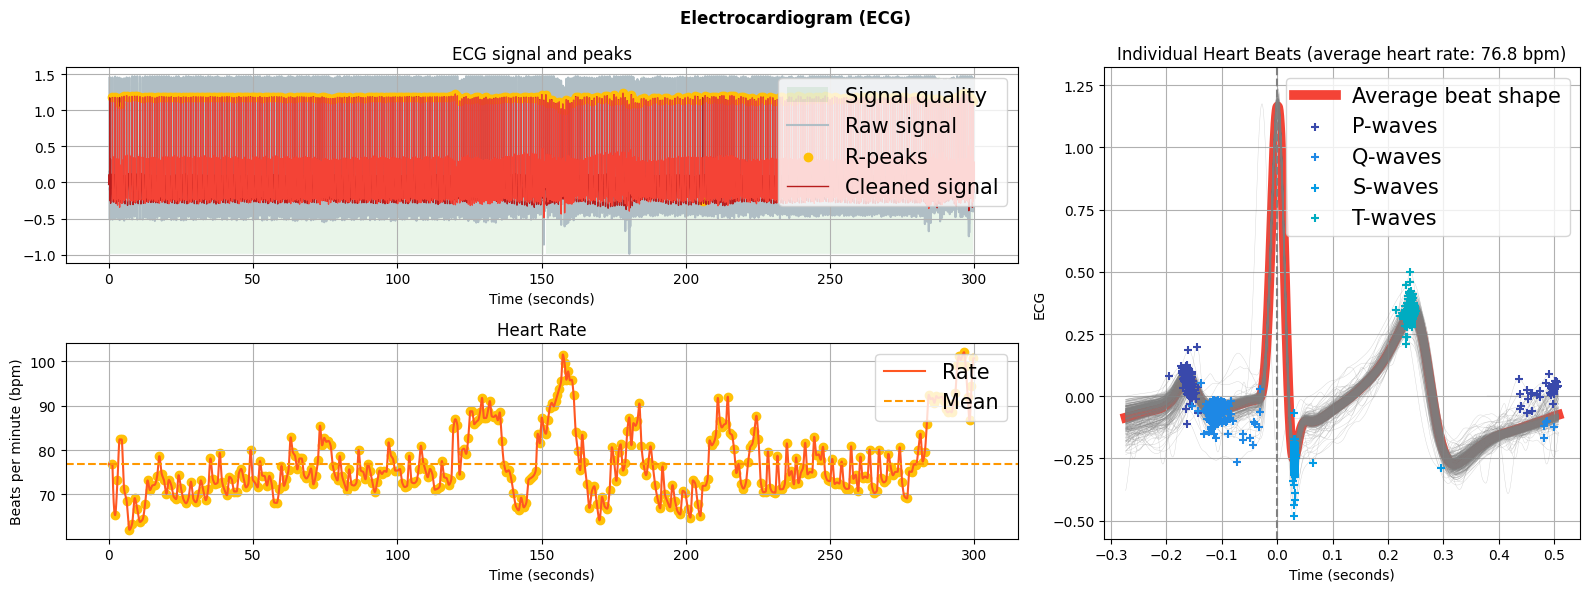

In [8]:
[ecg_vars, ecg_plt, ps_df, ecg_error] = ecg_qc(xdf_filename = xdf_filename, stim_df = stim_df, task='RestingState')

Effective sampling rate: 999.787 Hz
Signal Integrity Check: 100.000 %
Average Skin Conductance Level: 3.454 mS
Skin Conductance Level Standard deviation: 0.926 mS
Skin Conductance Level Coefficient of Variation: 26.802 %
Average Amplitude of Skin Conductance Response: 0.012 mS
Skin Conductance Response Validity: 33.333 %
Signal to Noise Ratio: 54.191 dB


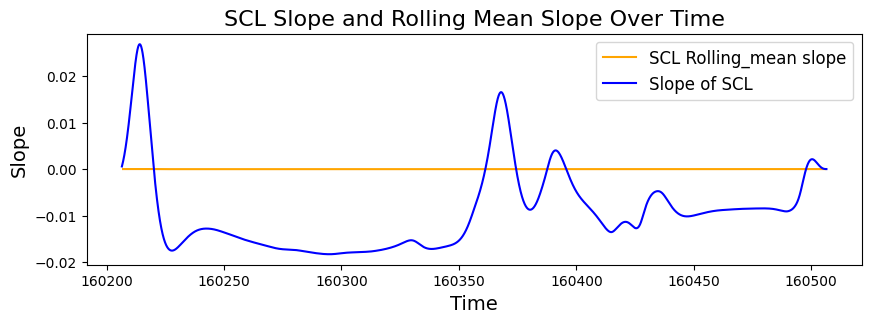

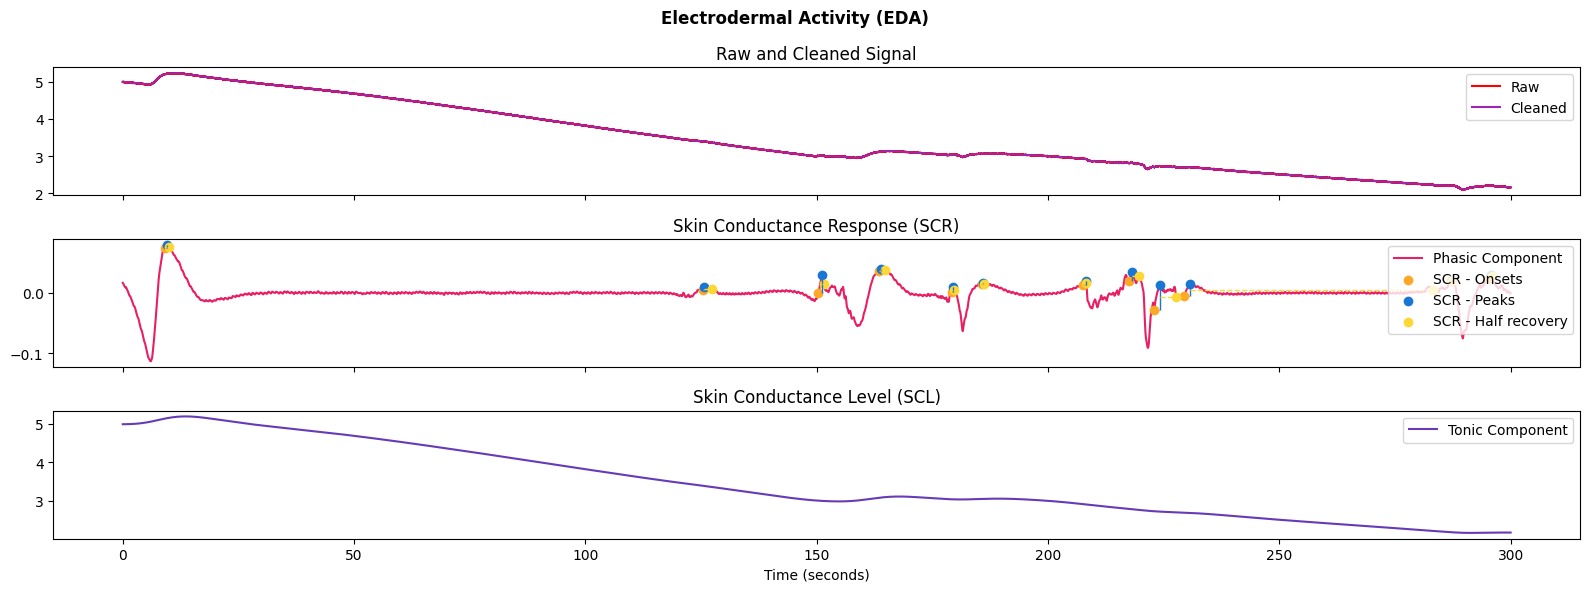

In [9]:
[eda_vars, eda_plt1, eda_plt2, ps_df, eda_error] = eda_qc(xdf_filename = xdf_filename, stim_df = stim_df, task= 'RestingState')

In [5]:
et_df = import_et_data(xdf_filename)
time_cols = et_df.filter(like = 'time').columns
val_cols = et_df.filter(like = 'validity').columns
qc_cols = time_cols.append(val_cols)
et_data_cols = et_df.columns.drop(qc_cols)

# percent non-NaN for each variable
val_df = pd.DataFrame(columns= ['variable', 'percent_valid'])
val_df['variable'] = et_data_cols

for i, var in enumerate(et_data_cols):
    val_df.loc[i, 'percent_valid'] = 1 - et_df[var].isna().mean()

In [18]:
root = val_df.loc[1, 'variable'].split("_in")[0]

In [19]:
val_df[val_df['variable'].str.contains(root)]

,variable,percent_valid
0,left_gaze_origin_in_user_coordinate_system_0,0.837203
1,left_gaze_origin_in_user_coordinate_system_1,0.837203
2,left_gaze_origin_in_user_coordinate_system_2,0.837203
6,left_gaze_origin_in_trackbox_coordinate_system_0,0.837203
7,left_gaze_origin_in_trackbox_coordinate_system_1,0.837203
8,left_gaze_origin_in_trackbox_coordinate_system_2,0.837203


In [14]:
re.sub(r"_\d+$", "", val_df.loc[1, 'variable'])

'left_gaze_origin_in_user_coordinate_system'

In [6]:
val_df

,variable,percent_valid
0,left_gaze_origin_in_user_coordinate_system_0,0.837203
1,left_gaze_origin_in_user_coordinate_system_1,0.837203
2,left_gaze_origin_in_user_coordinate_system_2,0.837203
3,right_gaze_origin_in_user_coordinate_system_0,0.804535
4,right_gaze_origin_in_user_coordinate_system_1,0.804535
5,right_gaze_origin_in_user_coordinate_system_2,0.804535
6,left_gaze_origin_in_trackbox_coordinate_system_0,0.837203
7,left_gaze_origin_in_trackbox_coordinate_system_1,0.837203
8,left_gaze_origin_in_trackbox_coordinate_system_2,0.837203
9,right_gaze_origin_in_trackbox_coordinate_system_0,0.804535


Effective sampling rate: 119.9959
Flag: all coordinates have the same % validity within each measure (LR, gaze point/origin/diameter): True
Flag: % of NaNs is the same between coordinate systems (UCS and TBCS (gaze origin) and between UCS and display area (gaze point)): True
Mean difference in percent valid data between right and left eyes: 3.2147%
Percent of data with gaze point differences of over 0.2 mm: 0.0991%


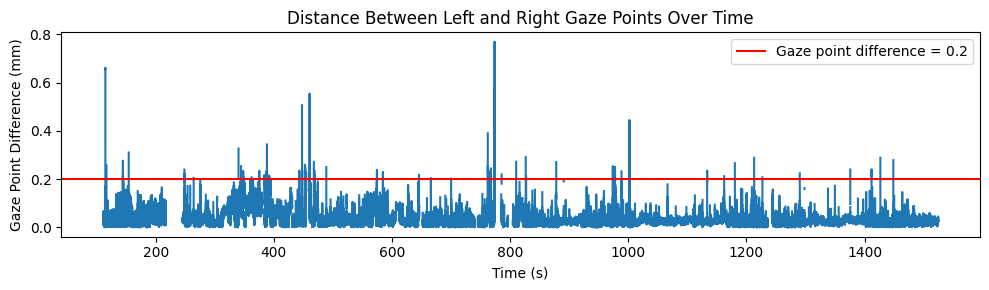

In [57]:
et_vars, et_df, et_error = et_qc(xdf_filename = xdf_filename, stim_df = stim_df, task='Experiment')

In [62]:
et_df.left_pupil_validity.mean()

np.float32(0.8352222)

In [63]:
et_df.left_gaze_origin_validity.mean()

np.float32(0.8372034)

In [24]:
stim_df = import_stim_data(xdf_filename)

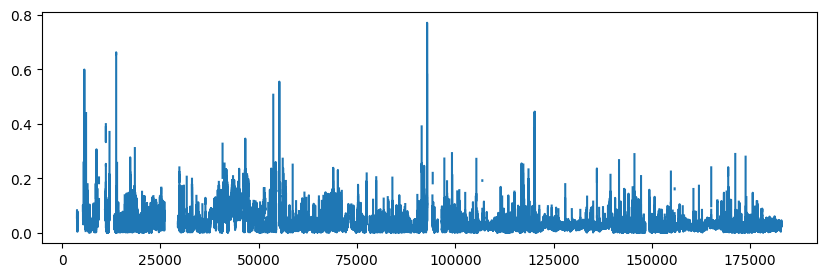

In [20]:
x1 = et_df.right_gaze_point_on_display_area_0
x2 = et_df.left_gaze_point_on_display_area_0
y1 = et_df.right_gaze_point_on_display_area_1
y2 = et_df.left_gaze_point_on_display_area_1
all_dists = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# plt with x = index 
plt.figure(figsize=(10, 3))
plt.plot(all_dists)

In [36]:
get_event_data(event = "RestingState", df = et_df, stim_df = stim_df)


,device_time_stamp,left_gaze_origin_validity,right_gaze_origin_validity,left_gaze_origin_in_user_coordinate_system_0,left_gaze_origin_in_user_coordinate_system_1,left_gaze_origin_in_user_coordinate_system_2,right_gaze_origin_in_user_coordinate_system_0,right_gaze_origin_in_user_coordinate_system_1,right_gaze_origin_in_user_coordinate_system_2,left_gaze_origin_in_trackbox_coordinate_system_0,...,left_gaze_point_on_display_area_1,right_gaze_point_on_display_area_0,right_gaze_point_on_display_area_1,left_pupil_validity,right_pupil_validity,left_pupil_diameter,right_pupil_diameter,lsl_time_stamp,time,diff
0,9.566562e+11,1.0,1.0,4.405524,-111.019165,735.597778,61.549683,-109.272552,732.750122,0.489389,...,0.448207,0.691243,0.446429,1.0,1.0,4.509247,4.642517,690748.387381,130.546076,0.008334
1,9.566562e+11,1.0,1.0,4.408916,-111.008789,735.613037,61.551483,-109.260887,732.720947,0.489383,...,0.457457,0.697706,0.437141,1.0,1.0,4.516434,4.643204,690748.395714,130.554410,0.008334
2,9.566562e+11,1.0,1.0,4.411083,-111.013176,735.598206,61.556595,-109.269203,732.748779,0.489379,...,0.460577,0.698299,0.440356,1.0,1.0,4.528885,4.636017,690748.404048,130.562744,0.008334
3,9.566562e+11,1.0,1.0,4.416933,-111.020081,735.628296,61.561199,-109.276588,732.762024,0.489368,...,0.452286,0.701809,0.431194,1.0,1.0,4.535110,4.641663,690748.412382,130.571077,0.008334
4,9.566562e+11,1.0,1.0,4.422386,-111.032257,735.597656,61.561455,-109.287781,732.730774,0.489358,...,0.456607,0.688949,0.452755,1.0,1.0,4.532745,4.673599,690748.420715,130.579411,0.008334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35994,9.569561e+11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,691048.347513,430.506209,0.008334
35995,9.569561e+11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,691048.355847,430.514542,0.008334
35996,9.569561e+11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,691048.364180,430.522876,0.008334
35997,9.569561e+11,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,691048.372514,430.531210,0.008334


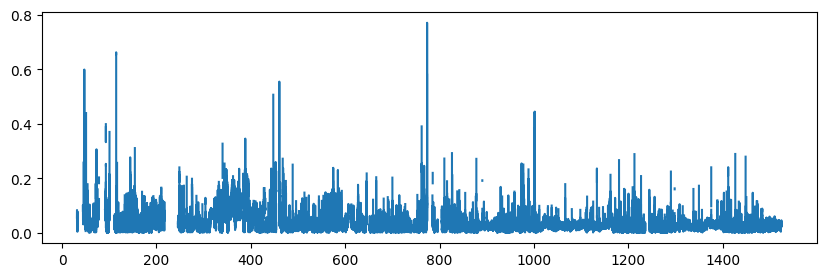

In [25]:
plt.figure(figsize=(10, 3))

plt.plot(et_df.time, all_dists)

In [28]:
et_df[["lsl_time_stamp", "time"]]

,lsl_time_stamp,time
0,690617.841304,0.000000
1,690617.849638,0.008334
2,690617.857972,0.016667
3,690617.866305,0.025001
4,690617.874639,0.033334
...,...,...
187763,693322.612947,2704.771642
187764,693322.621280,2704.779976
187765,693322.629614,2704.788310
187766,693322.637947,2704.796643


In [18]:
mic_df = get_event_data(event = 'RestingState', df = whole_mic_df, stim_df = stim_df)

In [38]:
time_cols = et_df.filter(like = 'time').columns
val_cols = et_df.filter(like = 'validity').columns
qc_cols = time_cols.append(val_cols)
et_data_cols = et_df.columns.drop(qc_cols)

# percent non-NaN for each variable
val_df = pd.DataFrame(columns= ['variable', 'percent_valid'])
val_df['variable'] = et_data_cols

for i, var in enumerate(et_data_cols):
    val_df.loc[i, 'percent_valid'] = 1 - et_df[var].isna().mean()

In [39]:
val_df

,variable,percent_valid
0,left_gaze_origin_in_user_coordinate_system_0,0.837203
1,left_gaze_origin_in_user_coordinate_system_1,0.837203
2,left_gaze_origin_in_user_coordinate_system_2,0.837203
3,right_gaze_origin_in_user_coordinate_system_0,0.804535
4,right_gaze_origin_in_user_coordinate_system_1,0.804535
5,right_gaze_origin_in_user_coordinate_system_2,0.804535
6,left_gaze_origin_in_trackbox_coordinate_system_0,0.837203
7,left_gaze_origin_in_trackbox_coordinate_system_1,0.837203
8,left_gaze_origin_in_trackbox_coordinate_system_2,0.837203
9,right_gaze_origin_in_trackbox_coordinate_system_0,0.804535


In [40]:
et_data_cols

Index(['left_gaze_origin_in_user_coordinate_system_0',
       'left_gaze_origin_in_user_coordinate_system_1',
       'left_gaze_origin_in_user_coordinate_system_2',
       'right_gaze_origin_in_user_coordinate_system_0',
       'right_gaze_origin_in_user_coordinate_system_1',
       'right_gaze_origin_in_user_coordinate_system_2',
       'left_gaze_origin_in_trackbox_coordinate_system_0',
       'left_gaze_origin_in_trackbox_coordinate_system_1',
       'left_gaze_origin_in_trackbox_coordinate_system_2',
       'right_gaze_origin_in_trackbox_coordinate_system_0',
       'right_gaze_origin_in_trackbox_coordinate_system_1',
       'right_gaze_origin_in_trackbox_coordinate_system_2',
       'left_gaze_point_in_user_coordinate_system_0',
       'left_gaze_point_in_user_coordinate_system_1',
       'left_gaze_point_in_user_coordinate_system_2',
       'right_gaze_point_in_user_coordinate_system_0',
       'right_gaze_point_in_user_coordinate_system_1',
       'right_gaze_point_in_user_coord

In [24]:
vars['sampling_rate'], vars['lsl_wav_duration_diff'], vars['num_NaN'], vars['percent_NaN'], vars['quan25'], vars['quan75'], vars['std'], vars['min'], vars['max'] = [0,0,0,0,0,0,0,0,0]


In [28]:
vars['quan75']

np.float64(0.0)

In [27]:
vars['sampling_rate'], vars['lsl_wav_duration_diff'], vars['num_NaN'], vars['percent_NaN'], vars['quan25'], vars['quan75'], vars['std'], vars['min'], vars['max'] = np.zeros(9)


# Testing other subs 

In [33]:
xdf_filename = "/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5738075/sub-P5738075_ses-S001_task-CUNY_run-001_mobi.xdf"

In [40]:
ps_df = import_physio_data(xdf_filename)

In [48]:
ps_df.loc[ps_df['RESPIRATION0'].isnull()]

,nSeq,RESPIRATION0,ECG1,EDA2,fSpO23,fSpO24,%SpO25,lsl_time_stamp,time


In [50]:
et_df = import_et_data(xdf_filename)

In [52]:
et_df.left_pupil_validity.mean()

np.float32(0.59288263)

In [11]:
et_df.left_gaze_point_validity.mean()

np.float32(0.59288263)

In [34]:
stim_df = import_stim_data(xdf_filename)

In [15]:
print(social_et_df.left_gaze_point_validity.mean())
print(social_et_df.right_gaze_point_validity.mean())
print(social_et_df.left_gaze_origin_validity.mean())
print(social_et_df.right_gaze_origin_validity.mean())

0.278804
0.004021745
0.28382427
0.0040494814


In [16]:
print(et_df.left_gaze_point_validity.mean())
print(et_df.right_gaze_point_validity.mean())
print(et_df.left_gaze_origin_validity.mean())
print(et_df.right_gaze_origin_validity.mean())

0.59288263
0.49728572
0.59555095
0.5001004


In [25]:
story_et_df = get_event_data('StoryListening', et_df, stim_df)
print(story_et_df.left_gaze_point_validity.mean())
print(story_et_df.right_gaze_point_validity.mean())
print(story_et_df.left_gaze_origin_validity.mean())
print(story_et_df.right_gaze_origin_validity.mean())

0.75872016
0.7465839
0.7596921
0.74930143


# Vars for P5548165

In [31]:
social_et_df = get_event_data('SocialTask', et_df, stim_df)
story_et_df = get_event_data('StoryListening', et_df, stim_df)

In [33]:
print(story_et_df.left_gaze_point_validity.mean())
print(story_et_df.right_gaze_point_validity.mean())
print(story_et_df.left_gaze_origin_validity.mean())
print(story_et_df.right_gaze_origin_validity.mean())

0.92505026
0.8969898
0.9273734
0.8982923


In [32]:
print(social_et_df.left_gaze_point_validity.mean())
print(social_et_df.right_gaze_point_validity.mean())
print(social_et_df.left_gaze_origin_validity.mean())
print(social_et_df.right_gaze_origin_validity.mean())

nan
nan
nan
nan


In [34]:
print(et_df.left_gaze_point_validity.mean())
print(et_df.right_gaze_point_validity.mean())
print(et_df.left_gaze_origin_validity.mean())
print(et_df.right_gaze_origin_validity.mean())

0.8352222
0.8030655
0.8372034
0.8045354


In [35]:
social_et_df

,device_time_stamp,left_gaze_origin_validity,right_gaze_origin_validity,left_gaze_origin_in_user_coordinate_system_0,left_gaze_origin_in_user_coordinate_system_1,left_gaze_origin_in_user_coordinate_system_2,right_gaze_origin_in_user_coordinate_system_0,right_gaze_origin_in_user_coordinate_system_1,right_gaze_origin_in_user_coordinate_system_2,left_gaze_origin_in_trackbox_coordinate_system_0,...,left_gaze_point_on_display_area_1,right_gaze_point_on_display_area_0,right_gaze_point_on_display_area_1,left_pupil_validity,right_pupil_validity,left_pupil_diameter,right_pupil_diameter,lsl_time_stamp,time,diff


# 5293813

In [2]:
from webcam_qc import *

In [3]:
subject = 'P5855990'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video_old.avi'
stim_df = import_stim_data(xdf_filename)

In [8]:
cam_df = import_webcam_data(xdf_filename)

In [ ]:
43489 see if any modalities have lsl time stmap greater than this

In [9]:
cam_df

,frame_num,time_pre,cap_time_ms,time_post,lsl_time_stamp,frame_time_sec,lsl_time_sec
0,1,1.736968e+09,6.177217e+08,1.736968e+09,41958.891118,0.000000,0.000000e+00
1,2,1.736968e+09,6.177218e+08,1.736968e+09,41958.924452,0.033333,3.333348e+01
2,3,1.736968e+09,6.177218e+08,1.736968e+09,41958.957785,0.066667,6.666697e+01
3,4,1.736968e+09,6.177218e+08,1.736968e+09,41958.991119,0.100000,1.000005e+02
4,5,1.736968e+09,6.177219e+08,1.736968e+09,41959.024452,0.133333,1.333339e+02
...,...,...,...,...,...,...,...
50742,50743,1.736969e+09,6.194146e+08,1.736969e+09,43650.298730,1692.900000,1.691408e+06
50743,50744,1.736969e+09,6.194147e+08,1.736969e+09,43650.332064,1692.933333,1.691441e+06
50744,50745,1.736969e+09,6.194147e+08,1.736969e+09,43650.365397,1692.966667,1.691474e+06
50745,50746,1.736969e+09,6.194147e+08,1.736969e+09,43650.398731,1693.000000,1.691508e+06


In [5]:
stim_df

,trigger,event,lsl_time_stamp,time
0,2.000000e+02,Onset_Experiment,41958.568955,0.000000
1,1.736968e+09,psychopy_time_stamp,41958.568967,0.000013
2,1.000000e+01,Onset_RestingState,41987.929899,29.360944
3,1.736968e+09,psychopy_time_stamp,41987.929909,29.360954
4,1.100000e+01,Offset_RestingState,42287.928288,329.359333
...,...,...,...,...
248,5.010000e+02,Offset_StoryListening,43489.444221,1530.875267
249,4.000000e+02,Onset_impedanceCheck,43489.444239,1530.875285
250,1.736969e+09,psychopy_time_stamp,43489.444240,1530.875286
251,4.010000e+02,Offset_impedanceCheck,43661.748294,1703.179340


In [4]:
webcam_vars, cam_df, cam_error = webcam_qc(xdf_filename=xdf_filename,
                                stim_df=stim_df,
                                video_file=video_filename, task='SocialTask')

IndexError: index 0 is out of bounds for axis 0 with size 0

In [6]:
cam_error

True

In [67]:
story_et_df = get_event_data('StoryListening', et_df, stim_df)
print(story_et_df.left_gaze_point_validity.mean())
print(story_et_df.right_gaze_point_validity.mean())
print(story_et_df.left_gaze_origin_validity.mean())
print(story_et_df.right_gaze_origin_validity.mean())

0.75872016
0.7465839
0.7596921
0.74930143


In [68]:
print(social_et_df.left_gaze_point_validity.mean())
print(social_et_df.right_gaze_point_validity.mean())
print(social_et_df.left_gaze_origin_validity.mean())
print(social_et_df.right_gaze_origin_validity.mean())

0.278804
0.004021745
0.28382427
0.0040494814


In [69]:
print(et_df.left_gaze_point_validity.mean())
print(et_df.right_gaze_point_validity.mean())
print(et_df.left_gaze_origin_validity.mean())
print(et_df.right_gaze_origin_validity.mean())

0.59288263
0.49728572
0.59555095
0.5001004


In [47]:
et_df.left_pupil_validity.mean()

np.float32(0.59288263)

In [48]:
et_df.right_pupil_validity.mean()

np.float32(0.49728572)

# 5198715

In [2]:
subject = 'P5198715'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'
stim_df = import_stim_data(xdf_filename)

In [3]:
et_df = import_et_data(xdf_filename)
et_df

,device_time_stamp,left_gaze_origin_validity,right_gaze_origin_validity,left_gaze_origin_in_user_coordinate_system_0,left_gaze_origin_in_user_coordinate_system_1,left_gaze_origin_in_user_coordinate_system_2,right_gaze_origin_in_user_coordinate_system_0,right_gaze_origin_in_user_coordinate_system_1,right_gaze_origin_in_user_coordinate_system_2,left_gaze_origin_in_trackbox_coordinate_system_0,...,left_gaze_point_on_display_area_1,right_gaze_point_on_display_area_0,right_gaze_point_on_display_area_1,left_pupil_validity,right_pupil_validity,left_pupil_diameter,right_pupil_diameter,lsl_time_stamp,time,diff
0,4.196161e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,707889.260620,0.000000,NaN
1,4.196169e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,707889.268954,0.008334,0.008334
2,4.196177e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,707889.277288,0.016667,0.008334
3,4.196186e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,707889.285621,0.025001,0.008334
4,4.196194e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,707889.293955,0.033334,0.008334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204771,5.902651e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,709595.743536,1706.482915,0.008334
204772,5.902660e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,709595.751869,1706.491249,0.008334
204773,5.902668e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,709595.760203,1706.499582,0.008334
204774,5.902676e+09,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,709595.768537,1706.507916,0.008334


In [7]:
et_df

""


In [5]:
plt.plot(et_df['lsl_time_stamp'], color = 'g')


KeyError: 'lsl_time_stamp'

In [5]:
et_nums = et_df[~np.isnan(et_df.left_gaze_point_on_display_area_0) &
        ~np.isnan(et_df.left_gaze_point_on_display_area_1) &
        ~np.isnan(et_df.right_gaze_point_on_display_area_0) &
        ~np.isnan(et_df.right_gaze_point_on_display_area_1)]

# distribution of distance between gaze points
x1 = et_nums.right_gaze_point_on_display_area_0
x2 = et_nums.left_gaze_point_on_display_area_0
y1 = et_nums.right_gaze_point_on_display_area_1
y2 = et_nums.left_gaze_point_on_display_area_1

In [14]:
et_df.left_gaze_point_on_display_area_0[et_df.left_gaze_point_on_display_area_0.notna()]

7927      0.481087
11489     0.734369
12283     1.280647
14848     0.638791
21710     0.609227
            ...   
177049    1.066759
177079    0.658146
194724    1.446998
198135    0.638538
204103    0.805537
Name: left_gaze_point_on_display_area_0, Length: 131, dtype: float32

In [15]:
et_df.left_gaze_point_on_display_area_1[et_df.left_gaze_point_on_display_area_1.notna()]

7927      0.767938
11489     0.939968
12283     1.034984
14848     1.030950
21710     0.886767
            ...   
177049    0.606737
177079   -0.154485
194724    0.997305
198135    0.373148
204103    0.732919
Name: left_gaze_point_on_display_area_1, Length: 131, dtype: float32

In [16]:
et_df.right_gaze_point_on_display_area_0[et_df.right_gaze_point_on_display_area_0.notna()]

1345      0.619247
1375      0.586953
1376      0.590089
1377      0.556421
1384      0.445562
            ...   
187343    0.854187
187344    0.866450
187345    0.866909
187347    0.874897
189838    0.811268
Name: right_gaze_point_on_display_area_0, Length: 164, dtype: float32

In [3]:
et_vars, et_df, et_error = et_qc(xdf_filename, stim_df = stim_df, task='Experiment')

Effective sampling rate: 119.9959
Percent invalid data in left gaze point: 99.93%
Percent invalid data in right gaze point: 99.92%
Percent invalid data in left gaze origin: 99.92%
Percent invalid data in right gaze origin: 99.91%
Percent invalid data in left pupil diameter: 99.93%
Percent invalid data in right pupil diameter: 99.92%
Flag: all coordinates have the same % validity within each measure (LR, gaze point/origin/diameter): True
Flag: % of NaNs is the same between coordinate systems (UCS and TBCS (gaze origin) and between UCS and display area (gaze point)): True
Mean difference in percent valid data between right and left eyes: 0.0136%
Error: Too much ET data missing to calculate metrics for participant P5198715 in /Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5198715/sub-P5198715_ses-S001_task-CUNY_run-001_mobi.xdf.


In [4]:
et_vars

{'sampling_rate': nan,
 'left_gaze_point_invalid': np.float32(99.933815),
 'right_gaze_point_invalid': np.float32(99.91586),
 'left_gaze_origin_invalid': np.float32(99.92355),
 'right_gaze_origin_invalid': np.float32(99.91432),
 'left_pupil_invalid': np.float32(99.933815),
 'right_pupil_invalid': np.float32(99.91586),
 'xyz_measures_check': nan,
 'coordinate_system_check': nan,
 'LR_mean_diff': nan,
 'percent_over02': nan}

In [76]:
print(et_df.left_gaze_point_validity.mean())
print(et_df.right_gaze_point_validity.mean())
print(et_df.left_gaze_origin_validity.mean())
print(et_df.right_gaze_origin_validity.mean())
print(et_df.left_pupil_validity.mean())
print(et_df.right_pupil_validity.mean())

0.0006397234
0.0008008751
0.0007422745
0.00082040863
0.0006397234
0.0008008751


In [79]:
story_et_df = get_event_data('StoryListening', et_df, stim_df)
print(story_et_df.left_gaze_point_validity.mean())
print(story_et_df.right_gaze_point_validity.mean())
print(story_et_df.left_gaze_origin_validity.mean())
print(story_et_df.right_gaze_origin_validity.mean())
print(story_et_df.left_pupil_validity.mean())
print(story_et_df.right_pupil_validity.mean())

0.00039635354
0.00033629997
0.00039635354
0.00034831068
0.00039635354
0.00033629997


In [ ]:
social_et_df = get_event_data('SocialTask', et_df, stim_df)
print(social_et_df.left_gaze_point_validity.mean())
print(social_et_df.right_gaze_point_validity.mean())
print(social_et_df.left_gaze_origin_validity.mean())
print(social_et_df.right_gaze_origin_validity.mean())
print(social_et_df.left_pupil_validity.mean())
print(social_et_df.right_pupil_validity.mean())

0.0007209006
0.001497255
0.0012199855
0.0015249819
0.0007209006
0.001497255


# P5548165

In [138]:
subject = 'P5548165'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'
stim_df = import_stim_data(xdf_filename)

In [139]:
et_df = import_et_data(xdf_filename)

In [82]:
social_et_df = get_event_data('SocialTask', et_df, stim_df)

In [134]:
print(et_df.left_gaze_point_validity.mean())
print(et_df.right_gaze_point_validity.mean())
print(et_df.left_gaze_origin_validity.mean())
print(et_df.right_gaze_origin_validity.mean())
print(et_df.right_gaze_origin_validity.mean())

0.8352222
0.8030655
0.8372034
0.8045354
0.8045354


In [83]:
story_et_df = get_event_data('StoryListening', et_df, stim_df)
print(story_et_df.left_gaze_point_validity.mean())
print(story_et_df.right_gaze_point_validity.mean())
print(story_et_df.left_gaze_origin_validity.mean())
print(story_et_df.right_gaze_origin_validity.mean())

0.92505026
0.8969898
0.9273734
0.8982923


In [84]:
print(social_et_df.left_gaze_point_validity.mean())
print(social_et_df.right_gaze_point_validity.mean())
print(social_et_df.left_gaze_origin_validity.mean())
print(social_et_df.right_gaze_origin_validity.mean())

nan
nan
nan
nan


In [ ]:
stim_time = stim_df.loc[stim_df.event == 'Onset_SocialTask', 'lsl_time_stamp'].values[0]
et_index = et_df.loc[et_df.lsl_time_stamp >= stim_time].index[0]

stim_time1 = stim_df.loc[stim_df.event == 'Offset_SocialTask', 'lsl_time_stamp'].values[0]
et_index1 = et_df.loc[et_df.lsl_time_stamp >= stim_time1].index[0]

/var/folders/8t/3zxw9ymj0dz7gvv5vyvt45j4wh1rnl/T/ipykernel_11162/2162298209.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


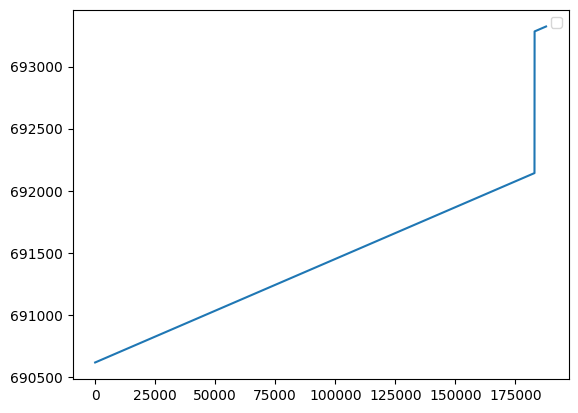

In [141]:
plt.plot(et_df.lsl_time_stamp)
# plt.hlines(stim_df.loc[stim_df.event == 'Onset_SocialTask', 'lsl_time_stamp'])

# plt.axvline(x=et_index, color='red', linestyle='--', label='Onset_SocialTask')
# plt.axvline(x=et_index1, color='orange', linestyle='--', label='Offset_SocialTask')
# plt.xlim([170000, 200000])
plt.legend()

In [131]:
percent_list = []
et_df['diff'] = et_df['lsl_time_stamp'].diff()
median = et_df['diff'].median() * 1.05
# number of loss instances  
loss_instances = (et_df['diff'] > median).sum()
if loss_instances != 0:
    # amount of data skipped: values for which diff>median 
    amt_data_lost = et_df.loc[et_df['diff'] > median, 'diff'].values[0].sum()
    # total amount of data: last - first lsl_time_stamp
    amt_data_total = et_df['lsl_time_stamp'].values[-1] - et_df['lsl_time_stamp'].values[0]
    
    percent_lost = amt_data_lost/amt_data_total * 100
else:
    percent_lost = 0
percent_list.append({'subject': 'p5548165', 'num_losses': loss_instances, 'percent_lost': f"{percent_lost:.4f}%"})

percent_data_loss = pd.DataFrame(percent_list)
percent_data_loss.sort_values(by='percent_lost', inplace=True, ascending=False)
nonzero_loss = percent_data_loss[percent_data_loss['num_losses'] != 0]
nonzero_loss

,subject,num_losses,percent_lost
0,p5548165,1,42.1485%


In [ ]:
eeg_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
ecg_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
eda_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
rsp_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
mic_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
et_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
webcam_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
duration_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])
lsl_iqr_df = pd.DataFrame(columns = ['name', 'value', 'IQR'])

iqr_map = {
    'eeg': [eeg_vars, eeg_iqr_df],
    'ecg': [ecg_vars, ecg_iqr_df],
    'eda': [eda_vars, eda_iqr_df],
    'rsp': [rsp_vars, rsp_iqr_df],
    'mic': [mic_vars, mic_iqr_df],
    'et': [et_vars, et_iqr_df],
    'webcam': [webcam_vars, webcam_iqr_df],
    'duration': [duration_vars, duration_iqr_df],
    'lsl': [lsl_vars, lsl_iqr_df]
}

In [ ]:
for stream in list(iqr_map.keys()):
    vars_dict = iqr_map[stream][0]
    iqr_df = iqr_map[stream][1]

    # if stream is duration or lsl and if first item is a df
    if (stream in ['duration', 'lsl'] and isinstance(list(vars_dict.values())[0], pd.DataFrame)):
        for df in vars_dict.values():
            df_to_dict = df.to_dict(orient = 'records')
            stream_vars = {}
            for i in range(len(df_to_dict)):
                stream_dict = {f"{df_to_dict[i]['stream']}_{k}": v for k, v in df_to_dict[i].items() if k not in ["stream", "subject"]}
                stream_vars.update(stream_dict)
            iqr_df['name'] = stream_vars.keys()
            iqr_df['value'] = stream_vars.values()    
    else:
        iqr_df['name'] = vars_dict.keys()
        iqr_df['value'] = [round(i, 4) if isinstance(i, float) else i for i in vars_dict.values()]
    iqr_df.fillna("", inplace = True)

In [ ]:
# create pdf about it

# Modalities and corresponding iqr dfs
metric_names = ["EEG", "ECG", "EDA", "RSP", "MIC","ET", "WEBCAM", "Stream Durations", "LSL"]
iqr_list = [eeg_iqr_df, ecg_iqr_df, eda_iqr_df, rsp_iqr_df, mic_iqr_df, et_iqr_df, webcam_iqr_df, duration_iqr_df, lsl_iqr_df]


# PDF structure
parent_folder = xdf_filename.split('mobi')[0]
pdf_path = f"{parent_folder}IQR_Report.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
elements = []
styles = getSampleStyleSheet()

# Define subtitle style if not already done
subtitle_style = ParagraphStyle(
    name="Subtitle",
    parent=styles["Heading2"],
    fontSize=14,
    leading=16,
    textColor="gray",
    spaceAfter=12,
    alignment=1  # Centered
)

# page number function
def add_page_number(canvas, doc):
    page_num = f'{canvas.getPageNumber()}'
    canvas.setFont("Helvetica", 9)
    canvas.drawRightString(570, 20, page_num)  # (x, y) from bottom-left


elements.append(Paragraph(f"Subject Report: {subject}", styles["Title"]))
elements.append(Paragraph(f"Collection Date: {get_collection_date(xdf_filename)}", subtitle_style))
elements.append(Spacer(1, 12))

# Format each metrics dict
for name, iqr_df in zip(metric_names, iqr_list):
    elements.append(Paragraph(name, styles["Heading2"]))
    headers = [str(col) for col in iqr_df.columns.tolist()]
    rows = [[str(cell) for cell in row] for row in iqr_df.values.tolist()]
    data = [headers] + rows  # Include headers
    table = Table(data, repeatRows=1)
    table.hAlign = 'LEFT'

    table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.lightgrey),
        ('GRID', (0, 0), (-1, -1), 0.5, colors.black),
        ('FONTNAME', (0, 0), (-1, -1), 'Helvetica'),
        ('FONTSIZE', (0, 0), (-1, -1), 10),
        ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
    ]))
    # elements.append(Paragraph(k, styles['Normal']))
    # elements.append(Spacer(1, 12))

    elements.append(table)
    elements.append(Spacer(1, 12))
    elements.append(Spacer(1, 12))

    # images
    folder = "report_images"
    image_keyword = name.lower()
    if os.path.exists(folder):
        row_images = []
        for fname in sorted(os.listdir(folder)):
            if image_keyword in fname.lower() and subject in fname:
                image_path = os.path.join(folder, fname)

                # get dimensions
                image_reader = ImageReader(image_path)
                orig_width, orig_height = image_reader.getSize()
                if orig_width > 4000:
                    img = Image(image_path, width=orig_width/9, height=orig_height/9)
                elif orig_width > 3000:
                    img = Image(image_path, width=orig_width/7, height=orig_height/7)
                elif orig_width > 2000:
                    img = Image(image_path, width=orig_width/5, height=orig_height/5)
                elif orig_width > 1400:
                    img = Image(image_path, width=orig_width/3, height=orig_height/3)
                else:
                    img = Image(image_path, width=orig_width/2, height=orig_height/2)

                # If 'rsp' in image name, add to a row
                if 'rsp' in fname.lower():
                    img.drawWidth = 250
                    img.drawHeight = 200
                    row_images.append(img)
                    
                    if len(row_images) == 2:
                        table = Table([row_images], hAlign = 'CENTER', colWidths=[280,280])
                        table.setStyle(TableStyle([('ALIGN', (0, 0), (0, -1), 'LEFT')]))
                        elements.append(table)
                        elements.append(Spacer(1, 12))
                        row_images = []

                else:
                    elements.append(img)
                    elements.append(Spacer(1, 12))

        # If there's an unmatched image left in the row buffer
        if row_images:
            elements.append(Table([row_images], hAlign='CENTER', colWidths='*'))
            elements.append(Spacer(1, 12))
            

doc.build(elements, onFirstPage = add_page_number, onLaterPages = add_page_number)
print(f'PDF created: {pdf_path}')

# 5855990

In [4]:
subject = 'P5248945'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'
stim_df = import_stim_data(xdf_filename)

In [5]:
behavior_vars, behavior_error = behavior_qc(xdf_filename, stim_df)

Missing stimulus markers: ['Offset_StoryListening', 'Onset_CampFriend', 'Offset_CampFriend', 'Onset_FrogDissection', 'Offset_FrogDissection', 'Onset_DanceContest', 'Offset_DanceContest', 'Onset_ZoomClass', 'Offset_ZoomClass', 'Offset_Tornado', 'Onset_BirthdayParty', 'Offset_BirthdayParty', 'Onset_subjectInput', 'Offset_subjectInput', 'Onset_FavoriteStory', 'Offset_FavoriteStory', 'Onset_WorstStory', 'Offset_WorstStory', 'Onset_impedanceCheck', 'Offset_impedanceCheck', 'Onset_SocialTask', 'Offset_SocialTask', 'Offset_Experiment']
Error: Missing stimulus markers for participant P5248945 in /Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5248945/sub-P5248945_ses-S001_task-CUNY_run-001_mobi.xdf.


In [6]:
behavior_vars

{'missing_stimulus_markers': ['Offset_StoryListening',
  'Onset_CampFriend',
  'Offset_CampFriend',
  'Onset_FrogDissection',
  'Offset_FrogDissection',
  'Onset_DanceContest',
  'Offset_DanceContest',
  'Onset_ZoomClass',
  'Offset_ZoomClass',
  'Offset_Tornado',
  'Onset_BirthdayParty',
  'Offset_BirthdayParty',
  'Onset_subjectInput',
  'Offset_subjectInput',
  'Onset_FavoriteStory',
  'Offset_FavoriteStory',
  'Onset_WorstStory',
  'Offset_WorstStory',
  'Onset_impedanceCheck',
  'Offset_impedanceCheck',
  'Onset_SocialTask',
  'Offset_SocialTask',
  'Offset_Experiment'],
 'total_duration': nan,
 'unexpected_durations': nan,
 'impedance_check_duration': nan,
 'ten_seconds_rest': nan,
 'average_response_time': nan}

In [13]:
wave.open("../../NEW_AUDIO_44/Camp_Lose_A_Friend.wav").getnframes()

6740160

In [10]:
error_log = []

In [4]:
total_experiment_duration(stim_df)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
if behavior_error and 'Offset_Experiment' in behavior_vars['missing_stimulus_markers']:
    behavior_print = {'Missing data error': f"Missing stimulus markers including Offset_Experiment for participant {subject} in {xdf_filename}.", 
                      'Missing stimulus markers': behavior_vars['missing_stimulus_markers']}
    error_log.append(behavior_print['Missing data error'])

In [13]:
if behavior_error and 'Offset_Experiment' in behavior_vars['missing_stimulus_markers']:
    behavior_print = {'Missing data error': f"Missing stimulus markers including Offset_Experiment for participant {subject} in {xdf_filename}.", 
                      'Missing stimulus markers': behavior_vars['missing_stimulus_markers']}
    error_log.append(behavior_print['Missing data error'])

{'Missing data error': 'Missing stimulus markers including Offset_Experiment for participant P5855990 in /Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5855990/sub-P5855990_ses-S001_task-CUNY_run-001_mobi.xdf.',
 'Missing stimulus markers': ['Onset_SocialTask',
  'Offset_SocialTask',
  'Offset_Experiment']}

# 5526515

In [16]:
subject = 'P5526515'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'
stim_df = import_stim_data(xdf_filename)

In [18]:
behavior_vars = behavior_qc(xdf_filename, stim_df)

Missing stimulus markers: ['Offset_StoryListening', 'Onset_CampFriend', 'Offset_CampFriend', 'Onset_FrogDissection', 'Offset_FrogDissection', 'Offset_DanceContest', 'Onset_ZoomClass', 'Offset_ZoomClass', 'Onset_Tornado', 'Offset_Tornado', 'Onset_BirthdayParty', 'Offset_BirthdayParty', 'Onset_subjectInput', 'Offset_subjectInput', 'Onset_FavoriteStory', 'Offset_FavoriteStory', 'Onset_WorstStory', 'Offset_WorstStory', 'Onset_impedanceCheck', 'Offset_impedanceCheck', 'Onset_SocialTask', 'Offset_SocialTask', 'Offset_Experiment']
Error: Missing stimulus markers include Offset_Experiment for participant P5526515 in /Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5526515/sub-P5526515_ses-S001_task-CUNY_run-001_mobi.xdf.


# 5248945

In [33]:
subject = 'P5248945'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'
stim_df = import_stim_data(xdf_filename)

In [29]:
stim_df

,trigger,event,lsl_time_stamp,time
0,2.000000e+02,Onset_Experiment,49939.216190,0.000000
1,1.749153e+09,psychopy_time_stamp,49939.216198,0.000008
2,1.000000e+01,Onset_RestingState,49962.711760,23.495570
3,1.749153e+09,psychopy_time_stamp,49962.711769,23.495579
4,1.100000e+01,Offset_RestingState,50262.712117,323.495928
5,1.749153e+09,psychopy_time_stamp,50262.712136,323.495946
6,5.000000e+02,Onset_StoryListening,50262.712204,323.496015
7,1.749153e+09,psychopy_time_stamp,50262.712206,323.496017
8,1.000000e+02,Onset_10second_rest,50349.746654,410.530464
9,1.749153e+09,psychopy_time_stamp,50349.746665,410.530476


In [23]:
ten_seconds_rest(stim_df)

True

In [31]:
ecg_vars, _, ecg_df, ecg_error = ecg_qc(xdf_filename, stim_df, 'Experiment')

IndexError: index 0 is out of bounds for axis 0 with size 0

In [32]:
behavior_vars

NameError: name 'behavior_vars' is not defined

In [20]:
behavior_vars = behavior_qc(xdf_filename)

Missing stimulus markers: ['Offset_StoryListening', 'Onset_CampFriend', 'Offset_CampFriend', 'Onset_FrogDissection', 'Offset_FrogDissection', 'Onset_DanceContest', 'Offset_DanceContest', 'Onset_ZoomClass', 'Offset_ZoomClass', 'Offset_Tornado', 'Onset_BirthdayParty', 'Offset_BirthdayParty', 'Onset_subjectInput', 'Offset_subjectInput', 'Onset_FavoriteStory', 'Offset_FavoriteStory', 'Onset_WorstStory', 'Offset_WorstStory', 'Onset_impedanceCheck', 'Offset_impedanceCheck', 'Onset_SocialTask', 'Offset_SocialTask', 'Offset_Experiment']


IndexError: index 0 is out of bounds for axis 0 with size 0

In [41]:
import glob
glob.glob('/'+xdf_filename)

['//Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5248945/sub-P5248945_ses-S001_task-CUNY_run-001_mobi.xdf']

In [43]:
import os

os.path.dirname(xdf_filename)

'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5248945'

# P5293813

In [8]:
subject = 'P5293813'
xdf_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'
video_filename = f'/Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-{subject}/sub-{subject}_task-CUNY_run-001_video.avi'

In [9]:
data, _ = pyxdf.load_xdf(xdf_filename, select_streams=[{'name':'Stimuli_Markers'}], verbose = False)
stim_df = pd.DataFrame(data[0]['time_series'])
stim_df.rename(columns={0: 'trigger'}, inplace=True)

events = {
    200: 'Onset_Experiment',
    10: 'Onset_RestingState',
    11: 'Offset_RestingState',
    500: 'Onset_StoryListening',
    501: 'Offset_StoryListening',
    100: 'Onset_10second_rest',
    101: 'Offset_10second_rest', 
    20: 'Onset_CampFriend',
    21: 'Offset_CampFriend',
    30: 'Onset_FrogDissection',
    31: 'Offset_FrogDissection',
    40: 'Onset_DanceContest',
    41: 'Offset_DanceContest',
    50: 'Onset_ZoomClass',
    51: 'Offset_ZoomClass',
    60: 'Onset_Tornado',
    61: 'Offset_Tornado',
    70: 'Onset_BirthdayParty',
    71: 'Offset_BirthdayParty',
    300: 'Onset_subjectInput',
    301: 'Offset_subjectInput',
    302: 'Onset_FavoriteStory',
    303: 'Offset_FavoriteStory',
    304: 'Onset_WorstStory',
    305: 'Offset_WorstStory',
    400: 'Onset_impedanceCheck',
    401: 'Offset_impedanceCheck',
    80: 'Onset_SocialTask',
    81: 'Offset_SocialTask',
    201: 'Offset_Experiment',
}

story_onsets = [20, 30, 40, 50, 60, 70]

# relabel the event if the trigger is in the events dictionary, else if 
stim_df['event'] = stim_df['trigger'].apply(lambda x: events[x] if x in events.keys() else 'Bx_input')

# relabel the event as a psychopy timestamp if the trigger is greater than 5 digits
stim_df.loc[stim_df.trigger.astype(str).str.len() > 5, 'event'] = 'psychopy_time_stamp'
stim_df['lsl_time_stamp'] = data[0]['time_stamps']
stim_df['time'] = (data[0]['time_stamps'] - data[0]['time_stamps'][0])


In [17]:
behavior_qc(xdf_filename, stim_df)

Missing stimulus markers: ['Onset_CampFriend', 'Offset_CampFriend', 'Onset_FrogDissection', 'Offset_FrogDissection', 'Onset_DanceContest', 'Offset_DanceContest', 'Onset_ZoomClass', 'Offset_ZoomClass', 'Onset_Tornado', 'Offset_Tornado', 'Onset_BirthdayParty', 'Offset_BirthdayParty']
Duration of experiment: 39:30
Error: Missing stimulus markers for participant P5293813 in /Users/camilla.strauss/Desktop/CUNY_Data/Data/sub-P5293813/sub-P5293813_ses-S001_task-CUNY_run-001_mobi.xdf.


({'missing_stimulus_markers': ['Onset_CampFriend',
   'Offset_CampFriend',
   'Onset_FrogDissection',
   'Offset_FrogDissection',
   'Onset_DanceContest',
   'Offset_DanceContest',
   'Onset_ZoomClass',
   'Offset_ZoomClass',
   'Onset_Tornado',
   'Offset_Tornado',
   'Onset_BirthdayParty',
   'Offset_BirthdayParty'],
  'total_duration': nan,
  'unexpected_durations': nan,
  'impedance_check_duration': nan,
  'ten_seconds_rest': nan,
  'average_response_time': nan},
 True)

In [14]:
audiofiles= [
    "src/NEW_AUDIO_44/Camp_Lose_A_Friend.wav",
    "src/NEW_AUDIO_44/Frog_Dissection_Disaster.wav",
    "src/NEW_AUDIO_44/I_Decided_To_Be_Myself_And_Won_A_Dance_Contest.wav",
    "src/NEW_AUDIO_44/I_Fully_Embarrassed_Myself_In_Zoom_Class1.wav",
    "src/NEW_AUDIO_44/Left_Home_Alone_in_a_Tornado.wav",
    "src/NEW_AUDIO_44/The_Birthday_Party_Prank_44.wav"
    ]

In [ ]:
get_seconds_between_triggers

In [7]:
unexpected_durations(stim_df, story_onsets, events, audiofiles)

NameError: name 'story_onsets' is not defined

# help

In [ ]:

def add_modality_name(modality_vars):
    for key, vars in modality_vars.items():
        if key not in ['duration', 'lsl']:
            vars = {f"{key}_{k}": value for k, value in vars.items()}
            modality_vars[key] = vars
    return modality_vars
modality_vars = add_modality_name(modality_vars)

In [ ]:
# make plots
import pandas as pd
def make_iqr_plots(xdf_filename, modality_vars):
    qc_metrics = pd.read_csv('CUNY_QC.csv')
    numeric_cols = qc_metrics.select_dtypes(include=['float64', 'int64']).columns
    subject = xdf_filename.split('sub-')[1].split('/')[0]
    for col in numeric_cols:
        plt.figure(figsize=(5, 2.5))
        sns.boxplot(x=qc_metrics[col], color='paleturquoise', width=0.2)
        sns.swarmplot(x=qc_metrics[col], color='black', size=6, alpha=0.7)
        for modality in modality_vars:
            if col in modality_vars[modality]:
                subject_value = modality_vars[modality][col]
                plt.axvline(subject_value, color='red', linestyle='dotted', linewidth=1, label=subject)
                #plt.vlines(subject_value, ymin=qc_metrics[col].min(), ymax=qc_metrics[col].max(), color='red', zorder=5, label=subject)
                break
        plt.text(
            plt.gca().get_xlim()[0], plt.gca().get_ylim()[0],
            f'N={qc_metrics.shape[0]}',
            fontsize=10,
            verticalalignment='bottom',
            horizontalalignment='left'
        )
        plt.xlabel(None)
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(f'report_images/{subject}_{col}_IQR.png')
        plt.show()